In [25]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = gpd.read_file('/Users/tommasobaresi/Desktop/Bayesian/ECEC/merged_ecec_province.geojson') # path
df.head()

,geo_point_2d,year,rip_code,rip_name,reg_code,reg_name,prov_code,prov_name,prov_name_upper,prov_name_lower,...,lifelong_learn,startup_ratio,GERD_total_intramural,public_coverage,private_coverage,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_maj_empl_rate,geometry
0,"{ ""lon"": 8.7167073316998636, ""lat"": 39.9896141...",2022,5,Isole,20,Sardegna,95,Oristano,ORISTANO,oristano,...,7.5,9.90,0.83,4.025045,5.813953,1186.043828,26.765653,1212.809481,4.873680,"MULTIPOLYGON (((8.27581 39.88234, 8.27496 39.8..."
1,"{ ""lon"": 10.892609586480846, ""lat"": 44.5367134...",2022,2,Nord-Est,8,Emilia-Romagna,36,Modena,MODENA,modena,...,13.4,7.31,2.16,7.078254,5.112072,597.383405,23.532704,621.571503,4.259347,"MULTIPOLYGON (((10.48041 44.1895, 10.48183 44...."
2,"{ ""lon"": 16.490288659417445, ""lat"": 38.8960158...",2022,4,Sud,18,Calabria,79,Catanzaro,CATANZARO,catanzaro,...,7.0,10.03,0.59,1.335648,6.411113,171.707359,0.000000,171.707359,3.975738,"POLYGON ((16.41984 38.55398, 16.42124 38.55287..."
3,"{ ""lon"": 12.439732254650272, ""lat"": 43.9268471...",2022,2,Nord-Est,8,Emilia-Romagna,99,Rimini,RIMINI,rimini,...,8.1,9.74,2.16,6.282562,3.984064,225.224487,0.444376,225.668863,4.708083,"POLYGON ((12.45062 44.16222, 12.44895 44.16278..."
4,"{ ""lon"": 13.726553612797131, ""lat"": 42.6453251...",2022,4,Sud,13,Abruzzo,67,Teramo,TERAMO,teramo,...,9.8,7.63,1.14,4.961958,4.134965,126.776381,18.014720,144.791102,2.794672,"POLYGON ((14.14626 42.53062, 14.14329 42.53276..."


Select the columns with numbers


In [27]:
num_df = df.select_dtypes(include="number")

num_df.columns.values

array(['fem_empl_rate', 'population', 'unempl_rate', 'part_rate',
       'empl_rate', 'empl_growth', 'inact_rate', 'fem_edu_rate',
       'male_edu_rate', 'service_empl_rate', 'GDP', 'n_large_comp',
       'n_self_empl', 'young_neet', 'fem_house_rate', 'foreign_rate',
       'n_members_family', 'elderly_in_care', 'house_price',
       'fertility_rate', 'first_birth_maternal_age',
       'avg_children_per_woman', 'dependency_rate', 'ageing_index',
       'net_migration_rate', 'adj_net_migration_rate', 'area_km2',
       'public_transport_supply', 'internet_coverage_rate',
       'graduate_mobility_rate', 'green_m2_capita', 'eco_urban_index',
       'per_capita_public_expenditure', 'ecec_participation', 'coverage',
       'urban_type', 'per_capita_user_contribution',
       'advanced_business_empl', 'lifelong_learn', 'startup_ratio',
       'GERD_total_intramural', 'public_coverage', 'private_coverage',
       'other_percapita_public_expenditure',
       'other_percapita_user_contrib', '

Analize only the variables related to ECEC and women labour

In [48]:
ecec_variables = [
    "ecec_participation", "coverage",
    "public_coverage", "private_coverage",
    "per_capita_public_expenditure", "per_capita_user_contribution",
    "other_percapita_public_expenditure", "other_percapita_user_contrib",
    "other_per_capita_expenditure"
]

# Variabili Lavoro Femminile
labour_variables = [
    "fem_empl_rate", "part_rate", "unempl_rate",
    "fem_edu_rate", "fem_house_rate", "fem_maj_empl_rate"
]

eda_df = num_df[ecec_variables + labour_variables]
eda_df



,ecec_participation,coverage,public_coverage,private_coverage,per_capita_public_expenditure,per_capita_user_contribution,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_empl_rate,part_rate,unempl_rate,fem_edu_rate,fem_house_rate,fem_maj_empl_rate
0,19.5,9.838998,4.025045,5.813953,685.676655,229.391324,1186.043828,26.765653,1212.809481,43.5,0.044271,13.6,0.149833,1.475850,4.873680
1,32.9,12.190326,7.078254,5.112072,2227.057806,414.225128,597.383405,23.532704,621.571503,65.9,0.058595,5.1,0.194783,0.681610,4.259347
2,3.3,7.746761,1.335648,6.411113,114.056364,15.546547,171.707359,0.000000,171.707359,34.9,0.042536,13.6,0.198824,1.148658,3.975738
3,27.2,10.266626,6.282562,3.984064,1981.979007,373.726172,225.224487,0.444376,225.668863,57.9,0.054481,6.7,0.209848,0.888753,4.708083
4,15.6,9.096924,4.961958,4.134965,794.486437,233.246278,126.776381,18.014720,144.791102,55.4,0.051762,6.3,0.197518,0.926232,2.794672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,10.2,7.385402,4.167182,3.218220,553.447333,66.666295,110.896357,0.422907,111.319264,35.2,0.044224,14.5,0.188605,1.068614,5.376815
103,14.6,12.508851,5.428369,7.080481,781.273779,204.576587,359.453387,54.240736,413.694123,56.2,0.050063,5.1,0.175783,1.156479,3.981380
104,9.6,9.158416,1.237624,7.920792,181.010149,26.579208,255.460396,0.000000,255.460396,26.6,0.035260,17.2,0.156642,1.089109,6.497325
105,4.4,4.155648,1.637073,2.518574,265.509382,17.155774,19.897620,0.000000,19.897620,41.9,0.047022,9.9,0.152868,0.868908,4.601973


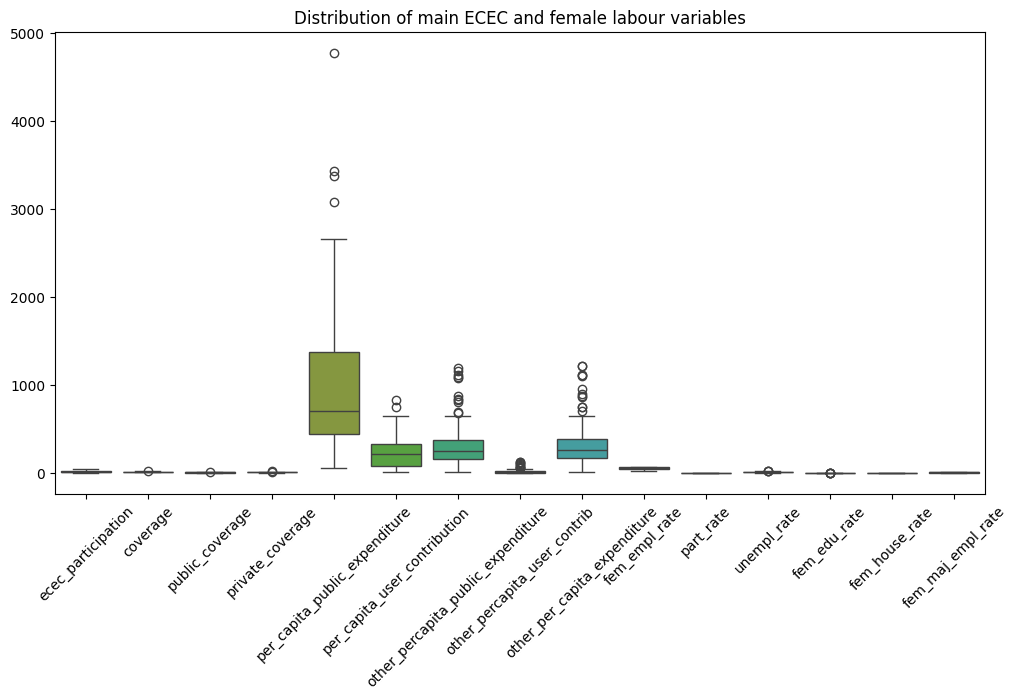

In [39]:
plt.figure(figsize=(12,6))
sns.boxplot(eda_df)
plt.xticks(rotation=45)
plt.title('Distribution of main ECEC and female labour variables')
plt.show()


Correlation matrix


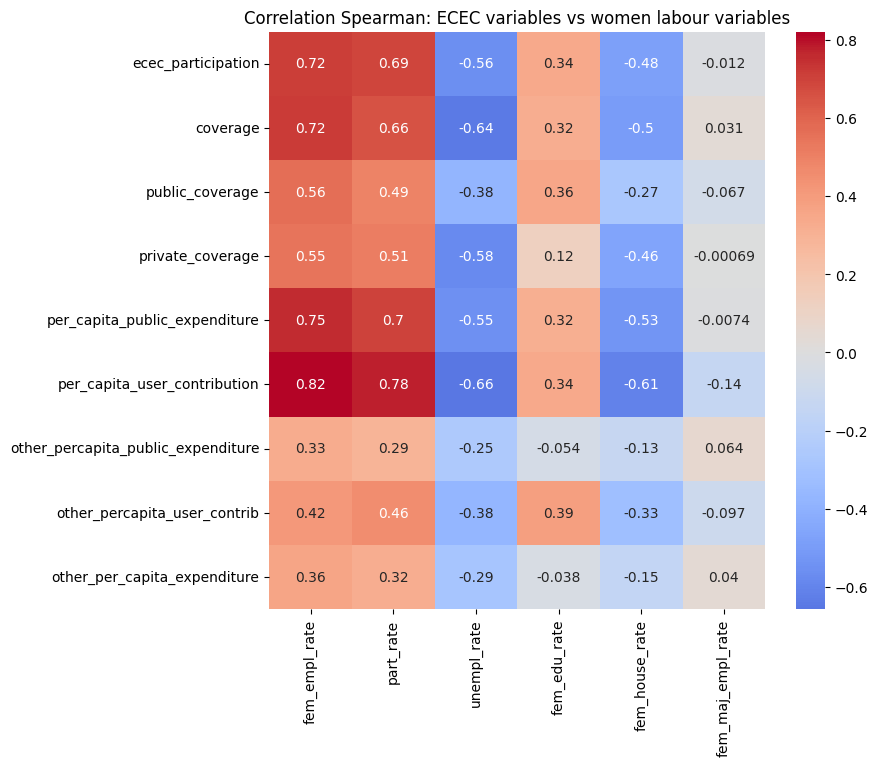

,fem_empl_rate,part_rate,unempl_rate,fem_edu_rate,fem_house_rate,fem_maj_empl_rate
ecec_participation,0.715655,0.692780,-0.558613,0.341399,-0.482837,-0.011849
coverage,0.720076,0.658565,-0.643399,0.324634,-0.503497,0.030731
public_coverage,0.561191,0.492045,-0.384518,0.357413,-0.273820,-0.067497
private_coverage,0.547589,0.509641,-0.577175,0.123881,-0.462848,-0.000686
per_capita_public_expenditure,0.751783,0.704883,-0.551809,0.318707,-0.532700,-0.007357
per_capita_user_contribution,0.820782,0.776828,-0.656018,0.341317,-0.607761,-0.141059
other_percapita_public_expenditure,0.325122,0.291062,-0.253311,-0.054233,-0.129323,0.064421
other_percapita_user_contrib,0.415965,0.456988,-0.378448,0.387612,-0.325544,-0.097335
other_per_capita_expenditure,0.360689,0.323772,-0.285296,-0.037981,-0.153353,0.039656


In [41]:
corr = num_df[ecec_variables + labour_variables].corr(method="spearman")

cross_corr = corr.loc[ecec_variables, labour_variables]

plt.figure(figsize=(8, len(ecec_variables)*0.5 + 3))
sns.heatmap(cross_corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Spearman: ECEC variables vs women labour variables")
plt.show()

cross_corr


Identify the strongest relationships between ECEC and female labour variables

In [ ]:
abs_corr = cross_corr.abs().stack().sort_values(ascending=False)
abs_corr


per_capita_user_contribution        fem_empl_rate        0.820782
                                    part_rate            0.776828
per_capita_public_expenditure       fem_empl_rate        0.751783
coverage                            fem_empl_rate        0.720076
ecec_participation                  fem_empl_rate        0.715655
per_capita_public_expenditure       part_rate            0.704883
ecec_participation                  part_rate            0.692780
coverage                            part_rate            0.658565
per_capita_user_contribution        unempl_rate          0.656018
coverage                            unempl_rate          0.643399
per_capita_user_contribution        fem_house_rate       0.607761
private_coverage                    unempl_rate          0.577175
public_coverage                     fem_empl_rate        0.561191
ecec_participation                  unempl_rate          0.558613
per_capita_public_expenditure       unempl_rate          0.551809
private_co

Spatial exploration

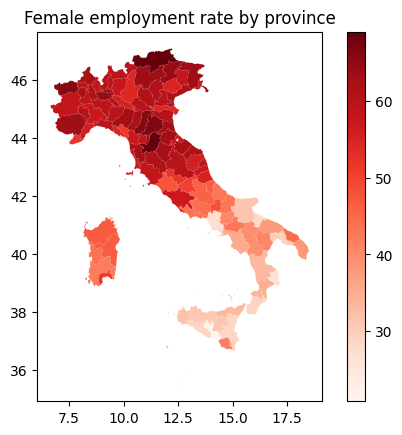

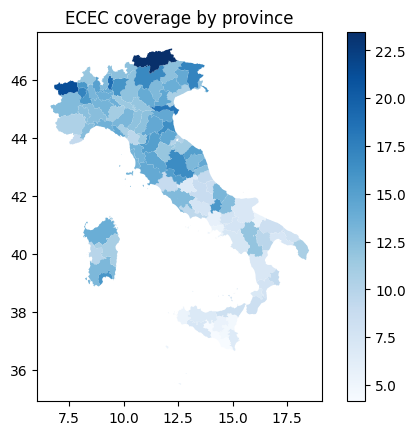

In [43]:
df.plot(column="fem_empl_rate", cmap="Reds", legend=True)
plt.title("Female employment rate by province")
plt.show()

df.plot(column="coverage", cmap="Blues", legend=True)
plt.title("ECEC coverage by province")
plt.show()
